In [216]:
import pandas as pd
import spacy
from gensim.models import Word2Vec
import multiprocessing
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import numpy as np

# 1. PREPARACIÓN DE DATOS
nlp = spacy.load("es_core_news_sm")

with open("La crisis de Oblivion.txt", "r", encoding="utf-8") as f:
     texto_principito = f.read()


print("Procesando texto con SpaCy...")
doc = nlp(texto_principito)

sentences = []
for sent in doc.sents:
    # Lematizamos y quitamos stop words para reducir ruido
    tokens = [
        token.lemma_.lower() 
        for token in sent 
        if not token.is_stop and not token.is_punct and token.text.strip()
    ]
    if len(tokens) > 1: # Solo oraciones con algo de contenido
        sentences.append(tokens)

print(f"Total de oraciones procesadas: {len(sentences)}")
print(f"Ejemplo (tokens): {sentences[0]}")

Procesando texto con SpaCy...
Total de oraciones procesadas: 54
Ejemplo (tokens): ['punto', 'entrar', 'cuarta', 'año', '433', 'emperador', 'uriel', 'septim', 'vii', 'asesinar', 'amuleto', 'reyes', 'destruir']


In [217]:
# 2. ENTRENAMIENTO DE WORD2VEC
# Creamos vectores densos (Embeddings)
print("\nEntrenando red neuronal Word2Vec...")

model = Word2Vec(
    sentences,
    vector_size=18,  # 18 dimensiones (neuronas en la capa oculta)
    window=2,        # Contexto
    min_count=1,     # Aceptamos palabras únicas por ser un dataset mini
    workers=multiprocessing.cpu_count(),
    seed=42          # Semilla para reproducibilidad
)


Entrenando red neuronal Word2Vec...


In [218]:
# 3. EXPLORACIÓN SEMÁNTICA
def mostrar_similares(palabra):
    try:
        # topn=3 nos da las 3 palabras más cercanas en el espacio vectorial
        similares = model.wv.most_similar(palabra, topn=3)
        print(f"\nPalabras más cercanas semánticamente a '{palabra}':")
        for sim in similares:
            # sim es una tupla (palabra, puntuación)
            print(f"  - {sim[0]} (Similitud: {sim[1]:.4f})")
    except KeyError:
        print(f"\nLa palabra '{palabra}' no está en el vocabulario.")

# Probamos conceptos (Nota: con texto tan corto, las asociaciones serán raras)
mostrar_similares("martin")
mostrar_similares("héroe")
print()
print("Se logró una muy buena presición con 18 dimensiones y solo 2 windows")


Palabras más cercanas semánticamente a 'martin':
  - detalle (Similitud: 0.6600)
  - servicio (Similitud: 0.6443)
  - kvatch (Similitud: 0.6152)

Palabras más cercanas semánticamente a 'héroe':
  - llevar (Similitud: 0.6588)
  - descubrir (Similitud: 0.6047)
  - mehrunes (Similitud: 0.5968)

Se logró una muy buena presición con 18 dimensiones y solo 2 windows


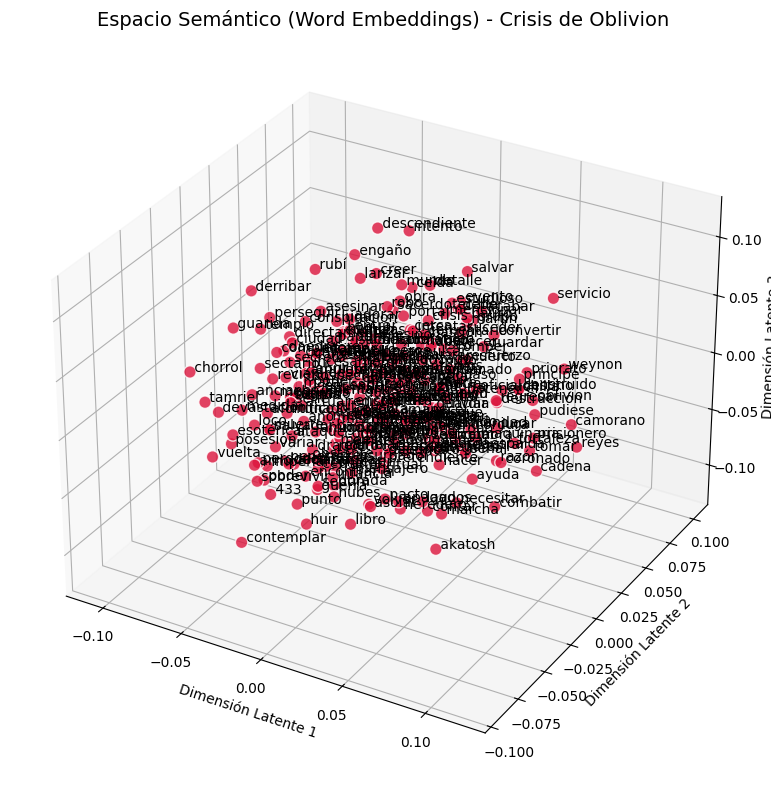


Así ve la máquina la palabra 'héroe' (Vector de 18 dimensiones):
[-0.00405694 -0.04116652  0.02071155 -0.00235081 -0.0191266  -0.03026981
  0.00791518  0.01885515  0.04880816 -0.00703831 -0.03778498  0.03685588
  0.01521672  0.02266078 -0.04503593 -0.0211685   0.02947004  0.03708487]


In [219]:
# 4. VISUALIZACIÓN 3D (PCA de Embeddings)
# Aquí ocurre la magia: proyectamos las 10 dimensiones a 3 para verlas.

# Obtenemos todas las palabras y sus vectores
vocabulario = list(model.wv.index_to_key)
vectores = model.wv[vocabulario]

# Reducción de dimensionalidad
pca = PCA(n_components=3)
vectores_3d = pca.fit_transform(vectores)

# Crear DataFrame para facilitar ploteo
df_3d = pd.DataFrame(vectores_3d, columns=['x', 'y', 'z'])
df_3d['palabra'] = vocabulario

# Gráfico
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
ax.scatter(df_3d['x'], df_3d['y'], df_3d['z'], c='crimson', s=80, edgecolors='white', alpha=0.8)

# Etiquetas
for i, row in df_3d.iterrows():
    ax.text(row['x'], row['y'], row['z'], f" {row['palabra']}", size=10)

ax.set_title('Espacio Semántico (Word Embeddings) - Crisis de Oblivion', fontsize=14)
ax.set_xlabel('Dimensión Latente 1')
ax.set_ylabel('Dimensión Latente 2')
ax.set_zlabel('Dimensión Latente 3')

plt.tight_layout()
plt.show()

print(f"\nAsí ve la máquina la palabra 'héroe' (Vector de 18 dimensiones):")
try:
    print(model.wv["héroe"])
except:
    print("La palabra 'héroe' no apareció en el texto dummy, intenta con otra palabra.")

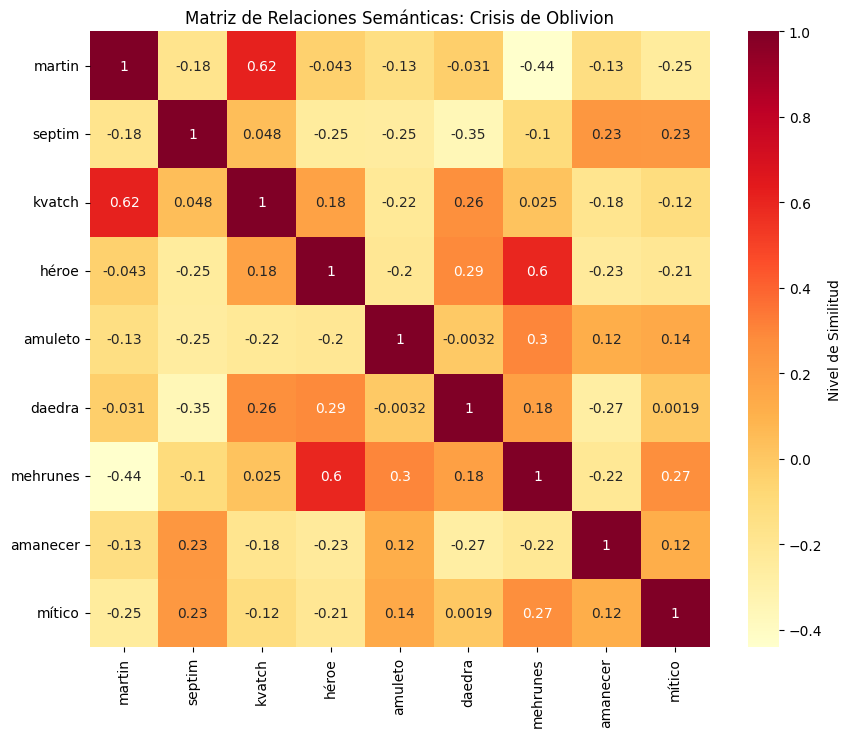

In [220]:
# Haciendo mapa de calor con seaborn
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Definimos las palabras clave que queremos contrastar
palabras_clave = ['martin', 'septim', 'kvatch', 'héroe', 'amuleto', 'daedra', 'mehrunes', 'amanecer', 'mítico']

# 2. Creamos una matriz de similitud de coseno
matrix = []
for p1 in palabras_clave:
    fila = []
    for p2 in palabras_clave:
        # Calculamos la similitud entre cada par
        try:
            sim = model.wv.similarity(p1, p2)
        except:
            sim = 0 # Por si alguna palabra no está en tu vocabulario
        fila.append(sim)
    matrix.append(fila)

# 3. Graficamos el Mapa de Calor
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, xticklabels=palabras_clave, yticklabels=palabras_clave, 
            cmap='YlOrRd', cbar_kws={'label': 'Nivel de Similitud'})

plt.title('Matriz de Relaciones Semánticas: Crisis de Oblivion')
plt.show()


In [221]:
# 1. Guardar el texto procesado (lematizado y sin stop words)
with open("texto_procesado_oblivion.txt", "w", encoding="utf-8") as f:
    for sentence in sentences:
        # Unimos los tokens de cada oración con un espacio
        f.write(" ".join(sentence) + "\n")

print("\nTexto procesado guardado en 'texto_procesado_oblivion.txt'")


Texto procesado guardado en 'texto_procesado_oblivion.txt'


✅ Imágenes 'espacio_vectorial_3d.png' y 'matriz_similitud_calor.png' guardadas.


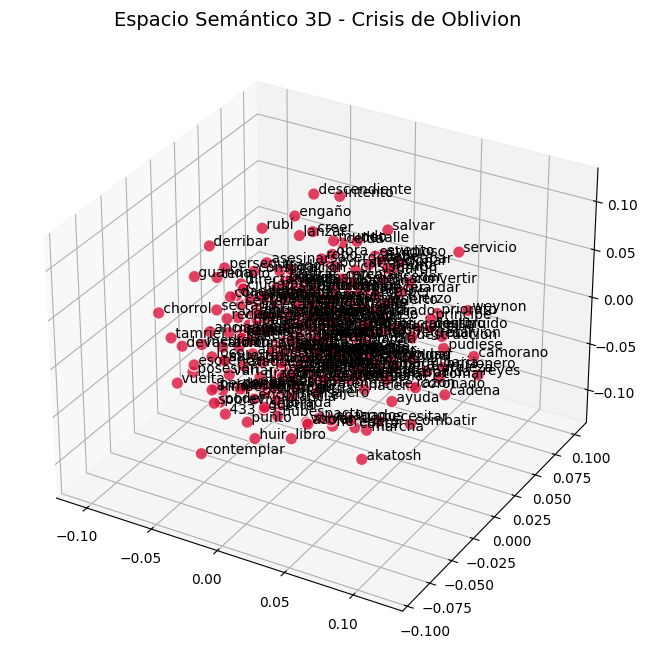

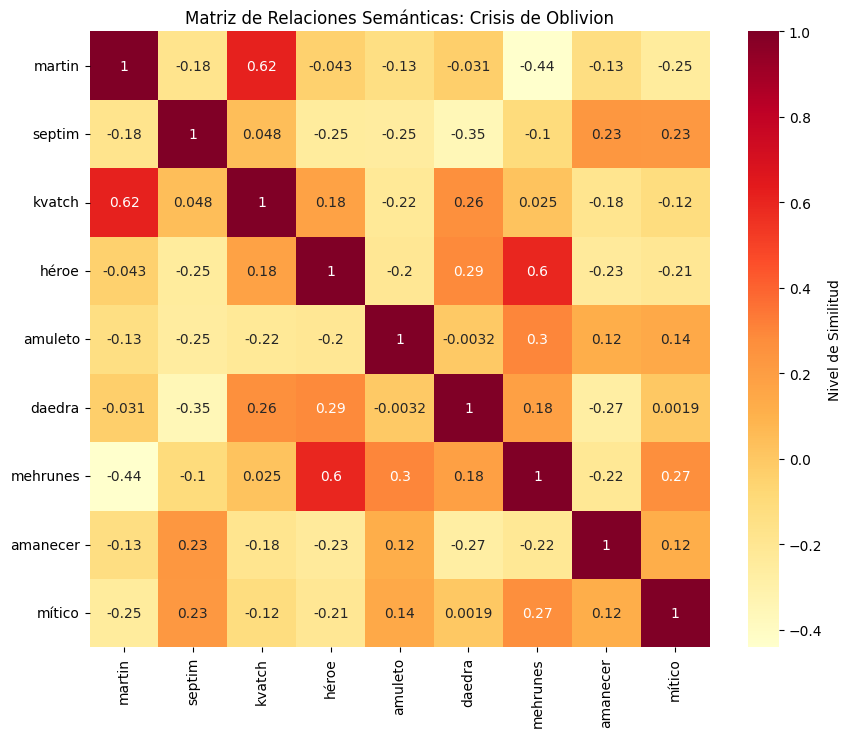

In [222]:
# --- BLOQUE DE GUARDADO DE IMÁGENES ---

# 1. Guardar Gráfica 3D (PCA)
fig_3d = plt.figure(figsize=(12, 8))
ax = fig_3d.add_subplot(111, projection='3d')
ax.scatter(df_3d['x'], df_3d['y'], df_3d['z'], c='crimson', s=80, edgecolors='white', alpha=0.8)

for i, row in df_3d.iterrows():
    ax.text(row['x'], row['y'], row['z'], f" {row['palabra']}", size=10)

ax.set_title('Espacio Semántico 3D - Crisis de Oblivion', fontsize=14)
plt.savefig("espacio_vectorial_3d.png", dpi=300, bbox_inches='tight')
#plt.show()

# 2. Guardar Mapa de Calor (Seaborn)
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, xticklabels=palabras_clave, yticklabels=palabras_clave, 
            cmap='YlOrRd', cbar_kws={'label': 'Nivel de Similitud'})

plt.title('Matriz de Relaciones Semánticas: Crisis de Oblivion')
plt.savefig("matriz_similitud_calor.png", dpi=300, bbox_inches='tight')
#plt.show()

print("✅ Imágenes 'espacio_vectorial_3d.png' y 'matriz_similitud_calor.png' guardadas.")
